In [1]:
import yfinance as yf
import pandas as pd

# 1. Bitcoin ka ticker symbol set karein
ticker = 'BTC-USD'

# 2. Last 5 years ka data download karein
# start aur end date manually bhi de sakte ho, ya 'period' use karo
data = yf.download(ticker, period='5y', interval='1d')

# 3. Data check karein
print("Data Shape:", data.shape)
print(data.head())

# 4. Ise future use ke liye save kar lo (Deep Analysis ke liye zaruri hai)
data.to_csv('bitcoin_5y_data.csv')
print("\nSuccess! Bitcoin data saved as 'bitcoin_5y_data.csv'")

[*********************100%***********************]  1 of 1 completed

Data Shape: (1827, 5)
Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2021-05-03  57200.292969  58973.308594  56590.871094  56620.273438   
2021-05-04  53333.539062  57214.179688  53191.425781  57214.179688   
2021-05-05  57424.007812  57911.363281  52969.054688  53252.164062   
2021-05-06  56396.515625  58363.316406  55382.507812  57441.308594   
2021-05-07  57356.402344  58606.632812  55321.847656  56413.953125   

Price            Volume  
Ticker          BTC-USD  
Date                     
2021-05-03  51713139031  
2021-05-04  68564706967  
2021-05-05  69241316747  
2021-05-06  69523285106  
2021-05-07  68434023376  

Success! Bitcoin data saved as 'bitcoin_5y_data.csv'


Success! Naye columns add ho gaye hain.
                   Close           MA7          MA21
2021-05-23  34770.582031  39120.571429  48910.415737
2021-05-24  38705.980469  38430.352679  48029.734189
2021-05-25  38402.222656  37786.469866  47318.719122
2021-05-26  39294.199219  38113.863839  46455.394903
2021-05-27  38436.968750  37778.753906  45600.178385


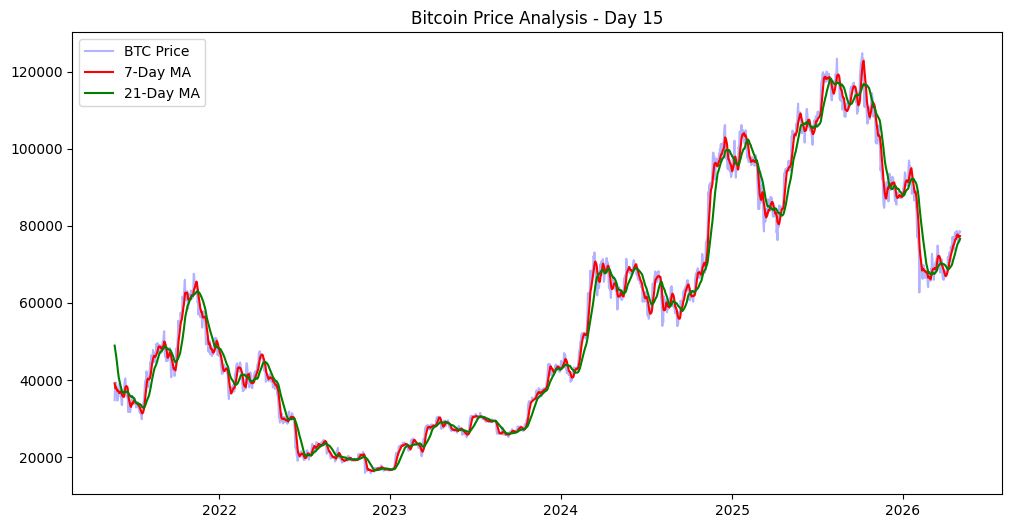

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data load karein
df = pd.read_csv('bitcoin_5y_data.csv', header=[0, 1, 2], index_col=0)

# 2. Multi-index ko flatten karein (Hume sirf 'Close' price chahiye)
# Aapki file mein Price -> Ticker -> BTC-USD ka structure hai
try:
    # Level 0 (Price) se 'Close' uthayenge
    df_close = df['Close']['BTC-USD'].copy()
except KeyError:
    # Agar structure thoda alag ho toh sirf 'Close' column ko dhoonde
    df_close = df.xs('Close', axis=1, level=0).iloc[:, 0].copy()

# DataFrame ko clean format mein convert karein
df_final = pd.DataFrame(df_close)
df_final.columns = ['Close']
df_final.index = pd.to_datetime(df_final.index)

# 3. Indicators calculate karein (Ab error nahi aayega)
df_final['MA7'] = df_final['Close'].rolling(window=7).mean()
df_final['MA21'] = df_final['Close'].rolling(window=21).mean()
df_final['Daily_Return'] = df_final['Close'].pct_change() * 100
df_final['Volatility'] = df_final['Daily_Return'].rolling(window=7).std()

# 4. NaNs drop karein
df_final.dropna(inplace=True)

print("Success! Naye columns add ho gaye hain.")
print(df_final[['Close', 'MA7', 'MA21']].head())

# 5. Graph plot karke check karein
plt.figure(figsize=(12,6))
plt.plot(df_final['Close'], label='BTC Price', color='blue', alpha=0.3)
plt.plot(df_final['MA7'], label='7-Day MA', color='red')
plt.plot(df_final['MA21'], label='21-Day MA', color='green')
plt.title('Bitcoin Price Analysis - Day 15')
plt.legend()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. Target Variable (Hume agle din ka price predict karna hai)
# Hum 'Close' price ko 1 din peeche shift karenge (Target)
df_final['Target'] = df_final['Close'].shift(-1)
df_final.dropna(inplace=True) # Last row mein target nahi hoga, use hatayein

# 2. Features (X) aur Target (y) select karein
X = df_final[['Close', 'MA7', 'MA21', 'Daily_Return', 'Volatility']]
y = df_final['Target']

# 3. Train-Test Split (80% training, 20% testing)
# Time-series mein shuffle=False rakhte hain taaki sequence bana rahe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Model Train karein
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Prediction aur Error check karein
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)

print(f"Model Trained! Average Error: ${error:.2f}")

Model Trained! Average Error: $6503.36


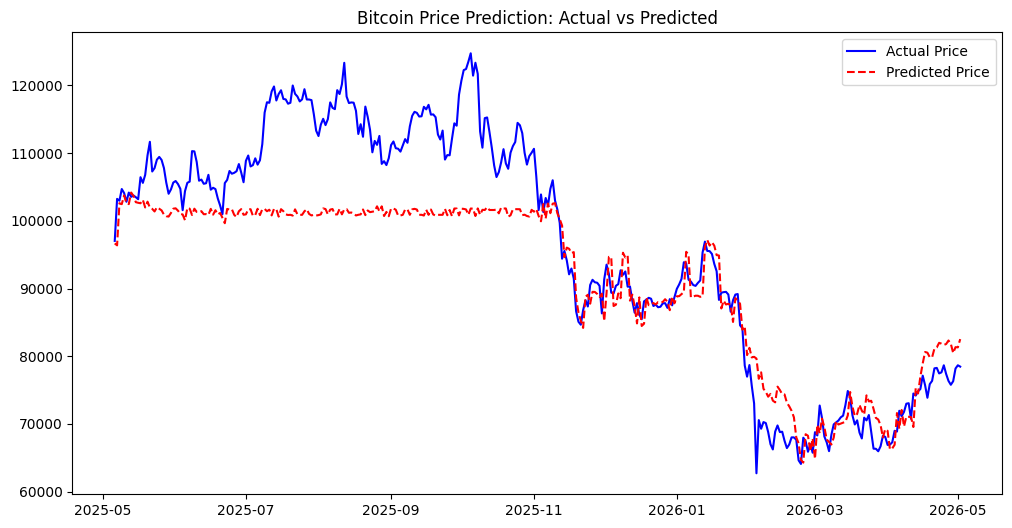

In [9]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='blue')
plt.plot(y_test.index, predictions, label='Predicted Price', color='red', linestyle='--')
plt.title('Bitcoin Price Prediction: Actual vs Predicted')
plt.legend()
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Model initialize aur train karein
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)

# Metrics check karein
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"--- Linear Regression Results ---")
print(f"MAE: ${lr_mae:.2f}")
print(f"R2 Score: {lr_r2:.4f}") # 1.0 ke jitna paas hoga, utna badiya

--- Linear Regression Results ---
MAE: $1452.68
R2 Score: 0.9871


XGBoost library missing. Run: pip install xgboost

--- Model Comparison Table ---
               Model          MAE
1  Linear Regression  1456.187680
0      Random Forest  6510.112636


C:\Users\JAISH DAHIYA\AppData\Local\Temp\ipykernel_35296\3028111078.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=results, palette='magma')


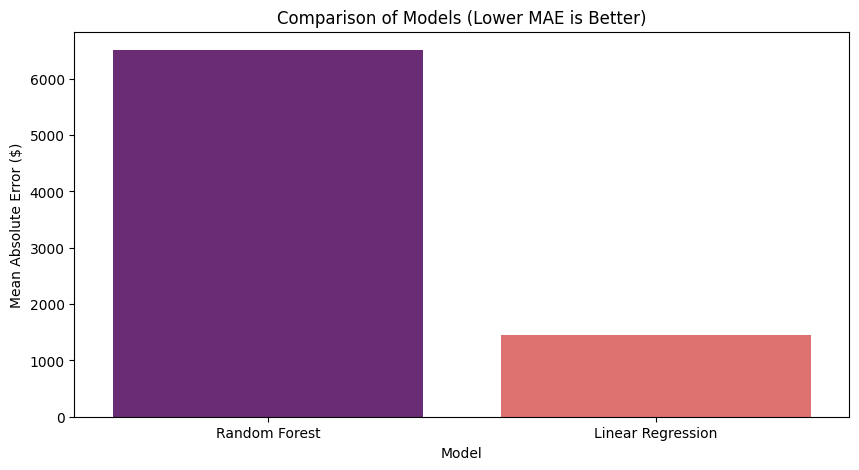

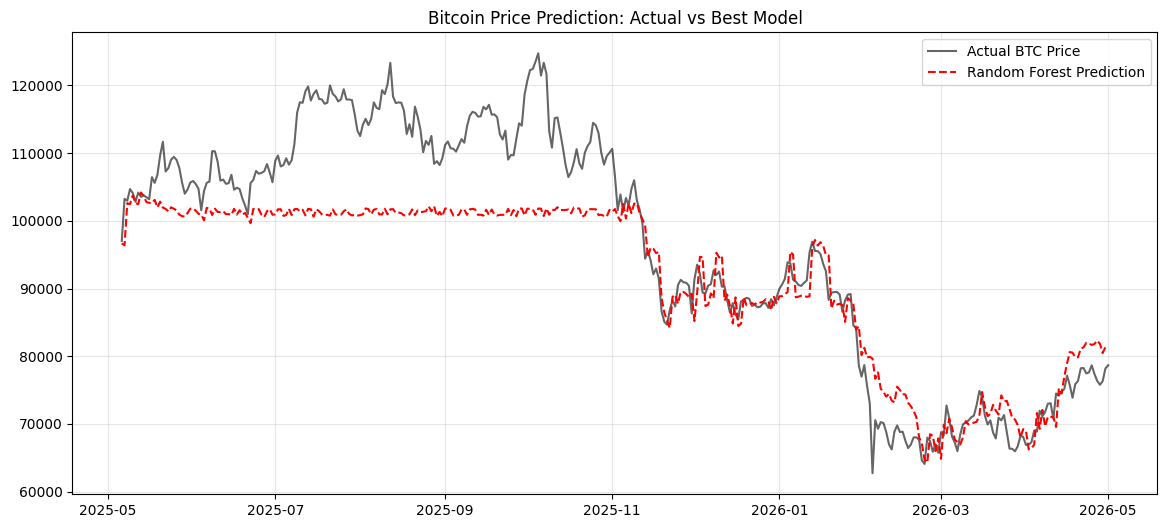

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# XGBoost ke liye check (agar install nahi hai toh error nahi dega)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost library missing. Run: pip install xgboost")

# 1. Target Column banana (Predicting next day's price)
df_final['Target'] = df_final['Close'].shift(-1)
df_ml = df_final.dropna().copy()

# 2. Features and Target
X = df_ml[['Close', 'MA7', 'MA21', 'Daily_Return', 'Volatility']]
y = df_ml['Target']

# 3. Train-Test Split (Time-series data: shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# --- MODEL 1: Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)

# --- MODEL 2: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)

# --- MODEL 3: XGBoost (Conditional) ---
model_names = ['Random Forest', 'Linear Regression']
mae_values = [rf_mae, lr_mae]
all_preds = {'RF': rf_preds, 'LR': lr_preds}

if xgb_available:
    xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, xgb_preds)
    
    model_names.append('XGBoost')
    mae_values.append(xgb_mae)
    all_preds['XGB'] = xgb_preds

# 4. Comparison Results
results = pd.DataFrame({'Model': model_names, 'MAE': mae_values})
print("\n--- Model Comparison Table ---")
print(results.sort_values(by='MAE'))

# 5. Visualizing the Error Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='MAE', data=results, palette='magma')
plt.title('Comparison of Models (Lower MAE is Better)')
plt.ylabel('Mean Absolute Error ($)')
plt.show()

# 6. Final Prediction Visualization (Comparing Best Model vs Actual)
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual BTC Price', color='black', alpha=0.6)
plt.plot(y_test.index, rf_preds, label='Random Forest Prediction', color='red', linestyle='--')
plt.title('Bitcoin Price Prediction: Actual vs Best Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

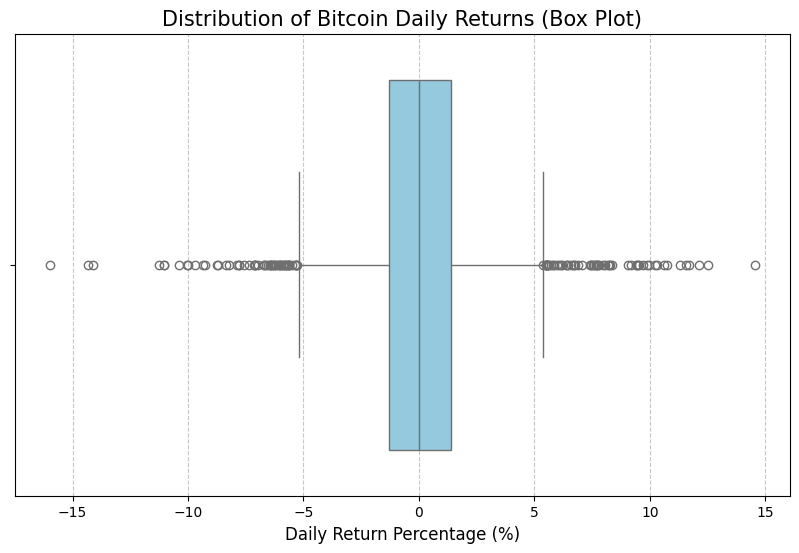

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Figure size set karein
plt.figure(figsize=(10, 6))

# 2. Boxplot banayein (Daily Returns column ka use karke)
sns.boxplot(x=df_final['Daily_Return'], color='skyblue')

# 3. Aesthetics aur Labels
plt.title('Distribution of Bitcoin Daily Returns (Box Plot)', fontsize=15)
plt.xlabel('Daily Return Percentage (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 4. Show plot
plt.show()

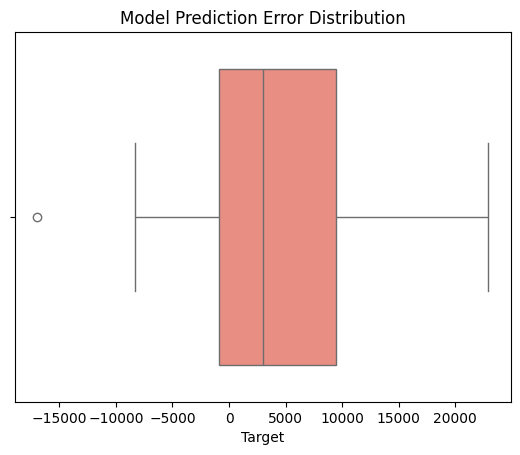

In [15]:
# Model residuals (galti) ka boxplot
residuals = y_test - rf_preds
sns.boxplot(x=residuals, color='salmon')
plt.title('Model Prediction Error Distribution')
plt.show()

In [16]:
# 1. Final DataFrame save karein jisme saare indicators aur predictions ka logic ho
df_ml.to_csv('bitcoin_final_processed_data.csv')

# 2. Model Performance Summary
print("\n--- Project Status ---")
print(f"Total Records Analyzed: {len(df_ml)}")
print(f"Best Model Performance (MAE): ${results['MAE'].min():.2f}")
print("Status: Model successfully trained and evaluated.")


--- Project Status ---
Total Records Analyzed: 1805
Best Model Performance (MAE): $1456.19
Status: Model successfully trained and evaluated.
